In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

project_path = '/content/drive/MyDrive/Spacecraft-Anomaly-Detection'
data_path = project_path + '/data/raw/archive/data/data'
train_path = data_path + '/train'
test_path = data_path + '/test'
labels_path = project_path + '/data/raw/archive/labeled_anomalies.csv'
results_path = project_path + '/results'

print("Project path:", project_path)
print("Train path exists:", os.path.exists(train_path))
print("Test path exists:", os.path.exists(test_path))
print("Labels path exists:", os.path.exists(labels_path))
print("Results path exists:", os.path.exists(results_path))

Mounted at /content/drive
Project path: /content/drive/MyDrive/Spacecraft-Anomaly-Detection
Train path exists: True
Test path exists: True
Labels path exists: True
Results path exists: True


#Load the Ground-Truth Labels

Now we need to understand which spacecraft channels have labeled anomalies across the dataset.

In [2]:
labels_df = pd.read_csv(labels_path)

print("First 5 rows:")
print(labels_df.head())

print("\nColumns:")
print(labels_df.columns.tolist())

print("\nNumber of labeled anomaly sequences:", len(labels_df))
print("Number of unique channels:", labels_df["chan_id"].nunique())

First 5 rows:
  chan_id spacecraft                           anomaly_sequences  \
0     P-1       SMAP  [[2149, 2349], [4536, 4844], [3539, 3779]]   
1     S-1       SMAP                              [[5300, 5747]]   
2     E-1       SMAP                [[5000, 5030], [5610, 6086]]   
3     E-2       SMAP                              [[5598, 6995]]   
4     E-3       SMAP                              [[5094, 8306]]   

                                  class  num_values  
0  [contextual, contextual, contextual]        8505  
1                               [point]        7331  
2              [contextual, contextual]        8516  
3                               [point]        8532  
4                               [point]        8307  

Columns:
['chan_id', 'spacecraft', 'anomaly_sequences', 'class', 'num_values']

Number of labeled anomaly sequences: 82
Number of unique channels: 81


###Inspect Anomaly Classes

In [3]:
print("Unique values in class column:")
print(labels_df["class"].unique())

print("\nData types in class column:")
print(labels_df["class"].map(type).value_counts())

Unique values in class column:
['[contextual, contextual, contextual]' '[point]'
 '[contextual, contextual]' '[contextual]' '[point, point, point]'
 '[point, contextual]' '[point, point]' '[contextual, point, contextual]']

Data types in class column:
class
<class 'str'>    82
Name: count, dtype: int64


#Anomaly Class Summary

In [4]:
class_counts = {}

for classes in labels_df["class"]:
    class_list = classes.strip("[]").split(", ")

    for anomaly_class in class_list:
        class_counts[anomaly_class] = class_counts.get(anomaly_class, 0) + 1

print("Anomaly class distribution:")
print(pd.Series(class_counts))

print("\nAnomaly records by spacecraft:")
spacecraft_class_counts = {}

for spacecraft, classes in zip(labels_df["spacecraft"], labels_df["class"]):
    class_list = classes.strip("[]").split(", ")

    for anomaly_class in class_list:
        key = (spacecraft, anomaly_class)
        spacecraft_class_counts[key] = spacecraft_class_counts.get(key, 0) + 1

print(pd.Series(spacecraft_class_counts))

Anomaly class distribution:
contextual    43
point         62
dtype: int64

Anomaly records by spacecraft:
SMAP  contextual    26
      point         43
MSL   point         19
      contextual    17
dtype: int64


####Check Channel Coverage

In [5]:
train_channels = sorted([
    file.replace(".npy", "")
    for file in os.listdir(train_path)
    if file.endswith(".npy")
])

test_channels = sorted([
    file.replace(".npy", "")
    for file in os.listdir(test_path)
    if file.endswith(".npy")
])

labeled_channels = sorted(labels_df["chan_id"].unique())

print("Training channels:", len(train_channels))
print("Test channels:", len(test_channels))
print("Labeled channels:", len(labeled_channels))

print("\nLabeled channels missing from training:")
print(sorted(set(labeled_channels) - set(train_channels)))

print("\nLabeled channels missing from test:")
print(sorted(set(labeled_channels) - set(test_channels)))

Training channels: 82
Test channels: 82
Labeled channels: 81

Labeled channels missing from training:
[]

Labeled channels missing from test:
[]


####Now We Check Channel Lengths

In [6]:
channel_lengths = []

for channel in labeled_channels:
    train_data = np.load(train_path + "/" + channel + ".npy")
    test_data = np.load(test_path + "/" + channel + ".npy")

    channel_lengths.append({
        "channel": channel,
        "spacecraft": labels_df.loc[
            labels_df["chan_id"] == channel, "spacecraft"
        ].iloc[0],
        "train_length": train_data.shape[0],
        "test_length": test_data.shape[0],
        "features": test_data.shape[1]
    })

channel_lengths_df = pd.DataFrame(channel_lengths)

print(channel_lengths_df.head(10))

print("\nTraining length range:")
print(
    channel_lengths_df["train_length"].min(),
    "to",
    channel_lengths_df["train_length"].max()
)

print("\nTest length range:")
print(
    channel_lengths_df["test_length"].min(),
    "to",
    channel_lengths_df["test_length"].max()
)

print("\nFeature counts:")
print(channel_lengths_df["features"].value_counts())

  channel spacecraft  train_length  test_length  features
0     A-1       SMAP          2880         8640        25
1     A-2       SMAP          2648         7914        25
2     A-3       SMAP          2736         8205        25
3     A-4       SMAP          2690         8080        25
4     A-5       SMAP           705         4693        25
5     A-6       SMAP           682         4453        25
6     A-7       SMAP          2879         8631        25
7     A-8       SMAP           762         8375        25
8     A-9       SMAP           762         8434        25
9     B-1       SMAP          2435         8044        25

Training length range:
312 to 4308

Test length range:
1096 to 8640

Feature counts:
features
25    54
55    27
Name: count, dtype: int64


###Check Anomaly Coverage

Now we need to see how much of each test channel is labeled as anomalous.

In [7]:
anomaly_summary = []

for _, row in labels_df.iterrows():
    channel = row["chan_id"]
    test_length = int(row["num_values"])

    sequences = row["anomaly_sequences"].strip("[]")
    sequence_pairs = sequences.split("], [")

    anomaly_points = 0

    for pair in sequence_pairs:
        pair = pair.strip("[]")
        start, end = map(int, pair.split(", "))
        anomaly_points += end - start + 1

    anomaly_summary.append({
        "channel": channel,
        "spacecraft": row["spacecraft"],
        "test_length": test_length,
        "anomaly_points": anomaly_points,
        "anomaly_percentage": (anomaly_points / test_length) * 100
    })

anomaly_summary_df = pd.DataFrame(anomaly_summary)

print(anomaly_summary_df.head(10))

print("\nAnomaly percentage statistics:")
print(anomaly_summary_df["anomaly_percentage"].describe())

  channel spacecraft  test_length  anomaly_points  anomaly_percentage
0     P-1       SMAP         8505             751            8.830100
1     S-1       SMAP         7331             448            6.111035
2     E-1       SMAP         8516             508            5.965242
3     E-2       SMAP         8532            1398           16.385373
4     E-3       SMAP         8307            3213           38.678223
5     E-4       SMAP         8354            2812           33.660522
6     E-5       SMAP         8294             321            3.870268
7     E-6       SMAP         8300              66            0.795181
8     E-7       SMAP         8310             281            3.381468
9     E-8       SMAP         8532             623            7.301922

Anomaly percentage statistics:
count    82.000000
mean     12.307316
std      14.424234
min       0.406184
25%       1.409118
50%       6.038139
75%      16.221680
max      50.109794
Name: anomaly_percentage, dtype: float64


##Verify Anomaly Sequence Counts

In [8]:
total_sequences = 0
point_sequences = 0
contextual_sequences = 0

for _, row in labels_df.iterrows():
    classes = row["class"].strip("[]").split(", ")

    total_sequences += len(classes)

    for anomaly_class in classes:
        if anomaly_class == "point":
            point_sequences += 1
        elif anomaly_class == "contextual":
            contextual_sequences += 1

print("Total anomaly sequences:", total_sequences)
print("Point anomaly sequences:", point_sequences)
print("Contextual anomaly sequences:", contextual_sequences)
print("Point + contextual:", point_sequences + contextual_sequences)

Total anomaly sequences: 105
Point anomaly sequences: 62
Contextual anomaly sequences: 43
Point + contextual: 105


###Create Ground-Truth Labels for All Channels

Now we'll convert the anomaly ranges into a clean 0/1 label array for every labeled channel.

In [9]:
ground_truth = {}

for _, row in labels_df.iterrows():
    channel = row["chan_id"]
    test_length = int(row["num_values"])

    labels = np.zeros(test_length, dtype=int)

    sequences = row["anomaly_sequences"].strip("[]")
    sequence_pairs = sequences.split("], [")

    for pair in sequence_pairs:
        pair = pair.strip("[]")
        start, end = map(int, pair.split(", "))
        labels[start:end + 1] = 1

    ground_truth[channel] = labels

print("Ground-truth labels created:", len(ground_truth))

for channel in list(ground_truth.keys())[:5]:
    print(
        channel,
        "length:", len(ground_truth[channel]),
        "anomaly points:", ground_truth[channel].sum()
    )

Ground-truth labels created: 81
P-1 length: 8505 anomaly points: 751
S-1 length: 7331 anomaly points: 448
E-1 length: 8516 anomaly points: 508
E-2 length: 8532 anomaly points: 1398
E-3 length: 8307 anomaly points: 3213


### Evaluation Function

In [10]:
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

def evaluate_predictions(y_true, y_pred):
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    false_positive_rate = fp / (fp + tn) if (fp + tn) > 0 else 0
    false_negative_rate = fn / (fn + tp) if (fn + tp) > 0 else 0

    return {
        "precision": precision,
        "recall": recall,
        "f1_score": f1,
        "false_positive_rate": false_positive_rate,
        "false_negative_rate": false_negative_rate,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp
    }

print("Evaluation function created successfully.")

Evaluation function created successfully.


##Test the Evaluation Function on A-8

In [11]:
a8_results = pd.read_csv(
    results_path + "/lstm_autoencoder_evaluation_A8.csv"
)

print("Saved A-8 LSTM results:")
print(a8_results)

Saved A-8 LSTM results:
  channel            method  window_size  \
0     A-8  LSTM Autoencoder           50   

                                   threshold_method  threshold  precision  \
0  99th percentile of training reconstruction error   0.116136   0.277507   

     recall  f1_score  false_positive_rate  false_negative_rate  TN    FP  \
0  0.447977  0.342714              0.98208             0.552023  81  4439   

     FN    TP  
0  2101  1705  


##Prepare the Evaluation Results Table

This cell creates an empty table where we will collect results from all channels and methods.

In [12]:
all_results = []

result_columns = [
    "channel",
    "spacecraft",
    "method",
    "precision",
    "recall",
    "f1_score",
    "false_positive_rate",
    "false_negative_rate",
    "TN",
    "FP",
    "FN",
    "TP"
]

results_df = pd.DataFrame(columns=result_columns)

print("Evaluation results table created.")
print("Columns:", results_df.columns.tolist())

Evaluation results table created.
Columns: ['channel', 'spacecraft', 'method', 'precision', 'recall', 'f1_score', 'false_positive_rate', 'false_negative_rate', 'TN', 'FP', 'FN', 'TP']


###Dataset-Wide Global Z-Score

This uses the same method from SERIAL 12, but now applies it to all 81 labeled channels.

Important: the threshold remains ±3, just as before. We are not tuning it using test labels.

In [13]:
global_zscore_results = []

for _, row in labels_df.iterrows():
    channel = row["chan_id"]
    spacecraft = row["spacecraft"]

    train_data = np.load(train_path + "/" + channel + ".npy")
    test_data = np.load(test_path + "/" + channel + ".npy")

    train_telemetry = train_data[:, 0]
    test_telemetry = test_data[:, 0]

    train_mean = np.mean(train_telemetry)
    train_std = np.std(train_telemetry)

    if train_std == 0:
        continue

    test_zscore = (test_telemetry - train_mean) / train_std
    y_pred = (np.abs(test_zscore) > 3).astype(int)

    y_true = ground_truth[channel]

    metrics = evaluate_predictions(y_true, y_pred)

    global_zscore_results.append({
        "channel": channel,
        "spacecraft": spacecraft,
        "method": "Global Z-score",
        **metrics
    })

global_zscore_df = pd.DataFrame(global_zscore_results)

print("Channels evaluated:", len(global_zscore_df))
print("\nFirst 10 results:")
print(global_zscore_df.head(10))

Channels evaluated: 68

First 10 results:
  channel spacecraft          method  precision    recall  f1_score  \
0     P-1       SMAP  Global Z-score   0.040323  0.006658  0.011429   
1     S-1       SMAP  Global Z-score   0.000000  0.000000  0.000000   
2     E-1       SMAP  Global Z-score   0.000000  0.000000  0.000000   
3     E-2       SMAP  Global Z-score   0.000000  0.000000  0.000000   
4     E-3       SMAP  Global Z-score   0.000000  0.000000  0.000000   
5     E-4       SMAP  Global Z-score   0.000000  0.000000  0.000000   
6     E-5       SMAP  Global Z-score   0.000000  0.000000  0.000000   
7     E-6       SMAP  Global Z-score   1.000000  0.181818  0.307692   
8     E-7       SMAP  Global Z-score   0.866667  0.138790  0.239264   
9     E-8       SMAP  Global Z-score   0.000000  0.000000  0.000000   

   false_positive_rate  false_negative_rate    TN   FP    FN  TP  
0             0.015347             0.993342  7635  119   746   5  
1             0.000000             1.00000

###Summarize Global Z-Score

In [14]:
print("Global Z-score dataset-wide summary")

print("\nMean metrics:")
print(
    global_zscore_df[
        ["precision", "recall", "f1_score",
         "false_positive_rate", "false_negative_rate"]
    ].mean()
)

print("\nMedian metrics:")
print(
    global_zscore_df[
        ["precision", "recall", "f1_score",
         "false_positive_rate", "false_negative_rate"]
    ].median()
)

print("\nTotal confusion matrix counts:")
print(
    "TN:", global_zscore_df["TN"].sum(),
    "FP:", global_zscore_df["FP"].sum(),
    "FN:", global_zscore_df["FN"].sum(),
    "TP:", global_zscore_df["TP"].sum()
)

Global Z-score dataset-wide summary

Mean metrics:
precision              0.262848
recall                 0.221878
f1_score               0.135430
false_positive_rate    0.094885
false_negative_rate    0.778122
dtype: float64

Median metrics:
precision              0.0
recall                 0.0
f1_score               0.0
false_positive_rate    0.0
false_negative_rate    1.0
dtype: float64

Total confusion matrix counts:
TN: 345447 FP: 38717 FN: 39835 TP: 12709


###Save Global Z-score Results

In [15]:
global_zscore_path = results_path + "/global_zscore_dataset_wide.csv"

global_zscore_df.to_csv(global_zscore_path, index=False)

print("Global Z-score results saved:")
print(global_zscore_path)
print("File exists:", os.path.exists(global_zscore_path))

Global Z-score results saved:
/content/drive/MyDrive/Spacecraft-Anomaly-Detection/results/global_zscore_dataset_wide.csv
File exists: True


###Dataset-Wide Rolling Z-Score

We will use the same past-only rolling window of 50 that we used in SERIAL 14.

This is important because using future test values to calculate the current threshold would cause data leakage.

In [16]:
rolling_zscore_results = []

window_size = 50
threshold = 3

for _, row in labels_df.iterrows():
    channel = row["chan_id"]
    spacecraft = row["spacecraft"]

    train_data = np.load(train_path + "/" + channel + ".npy")
    test_data = np.load(test_path + "/" + channel + ".npy")

    train_telemetry = train_data[:, 0]
    test_telemetry = test_data[:, 0]

    test_series = pd.Series(test_telemetry)

    rolling_mean = (
        test_series
        .shift(1)
        .rolling(window=window_size, min_periods=window_size)
        .mean()
    )

    rolling_std = (
        test_series
        .shift(1)
        .rolling(window=window_size, min_periods=window_size)
        .std()
    )

    rolling_z = (test_series - rolling_mean) / rolling_std

    y_pred = (rolling_z.abs() > threshold).fillna(False).astype(int).to_numpy()

    y_true = ground_truth[channel]

    metrics = evaluate_predictions(y_true, y_pred)

    rolling_zscore_results.append({
        "channel": channel,
        "spacecraft": spacecraft,
        "method": "Rolling Z-score",
        **metrics
    })

rolling_zscore_df = pd.DataFrame(rolling_zscore_results)

print("Channels evaluated:", len(rolling_zscore_df))
print("\nFirst 10 results:")
print(rolling_zscore_df.head(10))

Channels evaluated: 82

First 10 results:
  channel spacecraft           method  precision    recall  f1_score  \
0     P-1       SMAP  Rolling Z-score   0.187135  0.042610  0.069414   
1     S-1       SMAP  Rolling Z-score   0.075000  0.026786  0.039474   
2     E-1       SMAP  Rolling Z-score   0.067797  0.039370  0.049813   
3     E-2       SMAP  Rolling Z-score   0.145695  0.047210  0.071313   
4     E-3       SMAP  Rolling Z-score   0.397436  0.028945  0.053960   
5     E-4       SMAP  Rolling Z-score   0.314815  0.054410  0.092784   
6     E-5       SMAP  Rolling Z-score   0.041812  0.037383  0.039474   
7     E-6       SMAP  Rolling Z-score   0.015625  0.075758  0.025907   
8     E-7       SMAP  Rolling Z-score   0.108911  0.039146  0.057592   
9     E-8       SMAP  Rolling Z-score   0.041509  0.035313  0.038161   

   false_positive_rate  false_negative_rate    TN   FP    FN   TP  
0             0.017926             0.957390  7615  139   719   32  
1             0.021502       

###Summarize Rolling Z-score

In [17]:
print("Rolling Z-score dataset-wide summary")

print("\nMean metrics:")
print(
    rolling_zscore_df[
        ["precision", "recall", "f1_score",
         "false_positive_rate", "false_negative_rate"]
    ].mean()
)

print("\nMedian metrics:")
print(
    rolling_zscore_df[
        ["precision", "recall", "f1_score",
         "false_positive_rate", "false_negative_rate"]
    ].median()
)

print("\nTotal confusion matrix counts:")
print(
    "TN:", rolling_zscore_df["TN"].sum(),
    "FP:", rolling_zscore_df["FP"].sum(),
    "FN:", rolling_zscore_df["FN"].sum(),
    "TP:", rolling_zscore_df["TP"].sum()
)

Rolling Z-score dataset-wide summary

Mean metrics:
precision              0.367729
recall                 0.061518
f1_score               0.075961
false_positive_rate    0.026550
false_negative_rate    0.938482
dtype: float64

Median metrics:
precision              0.203142
recall                 0.042746
f1_score               0.056418
false_positive_rate    0.022850
false_negative_rate    0.957254
dtype: float64

Total confusion matrix counts:
TN: 440521 FP: 12539 FN: 62507 TP: 2197


###Save Rolling Z-score Results

In [18]:
rolling_zscore_path = results_path + "/rolling_zscore_dataset_wide.csv"

rolling_zscore_df.to_csv(rolling_zscore_path, index=False)

print("Rolling Z-score results saved:")
print(rolling_zscore_path)
print("File exists:", os.path.exists(rolling_zscore_path))

Rolling Z-score results saved:
/content/drive/MyDrive/Spacecraft-Anomaly-Detection/results/rolling_zscore_dataset_wide.csv
File exists: True


###Find Duplicate Channel Labels

In [19]:
duplicate_channels = labels_df[
    labels_df["chan_id"].duplicated(keep=False)
].sort_values("chan_id")

print("Duplicate channel labels:")
print(duplicate_channels)

print("\nNumber of duplicate channel rows:", len(duplicate_channels))
print("Duplicate channel IDs:", duplicate_channels["chan_id"].unique().tolist())

Duplicate channel labels:
   chan_id spacecraft anomaly_sequences    class  num_values
17     P-2       SMAP    [[5350, 6575]]  [point]        8209
51     P-2       SMAP    [[5300, 6420]]  [point]        8209

Number of duplicate channel rows: 2
Duplicate channel IDs: ['P-2']


We found the issue: P-2 appears twice, with two separate anomaly intervals.

This means our original ground_truth construction overwrote the first P-2 row with the second one. We should correct that before trusting the dataset-wide comparison.

###Rebuild Ground-Truth Labels Correctly

This combines all anomaly sequences belonging to the same channel

In [20]:
ground_truth = {}

for channel, group in labels_df.groupby("chan_id"):
    test_length = int(group["num_values"].iloc[0])

    labels = np.zeros(test_length, dtype=int)

    for _, row in group.iterrows():
        sequences = row["anomaly_sequences"].strip("[]")
        sequence_pairs = sequences.split("], [")

        for pair in sequence_pairs:
            pair = pair.strip("[]")
            start, end = map(int, pair.split(", "))
            labels[start:end + 1] = 1

    ground_truth[channel] = labels

print("Ground-truth labels created:", len(ground_truth))

print("\nP-2 ground-truth anomaly points:", ground_truth["P-2"].sum())

print("\nP-2 anomaly intervals:")
for _, row in labels_df[labels_df["chan_id"] == "P-2"].iterrows():
    print(row["anomaly_sequences"])

Ground-truth labels created: 81

P-2 ground-truth anomaly points: 1276

P-2 anomaly intervals:
[[5350, 6575]]
[[5300, 6420]]


##Recalculate Global Z-score with Correct Labels

Our earlier Global Z-score results used the old ground_truth, so the P-2 result may be incorrect. We'll recalculate it using the corrected labels.

In [21]:
global_zscore_results = []

for _, row in labels_df.drop_duplicates("chan_id").iterrows():
    channel = row["chan_id"]
    spacecraft = row["spacecraft"]

    train_data = np.load(train_path + "/" + channel + ".npy")
    test_data = np.load(test_path + "/" + channel + ".npy")

    train_telemetry = train_data[:, 0]
    test_telemetry = test_data[:, 0]

    train_mean = np.mean(train_telemetry)
    train_std = np.std(train_telemetry)

    if train_std == 0:
        continue

    test_zscore = (test_telemetry - train_mean) / train_std
    y_pred = (np.abs(test_zscore) > 3).astype(int)

    y_true = ground_truth[channel]

    metrics = evaluate_predictions(y_true, y_pred)

    global_zscore_results.append({
        "channel": channel,
        "spacecraft": spacecraft,
        "method": "Global Z-score",
        **metrics
    })

global_zscore_df = pd.DataFrame(global_zscore_results)

print("Channels evaluated:", len(global_zscore_df))
print("P-2 included:", "P-2" in global_zscore_df["channel"].values)

Channels evaluated: 67
P-2 included: True


The corrected Global Z-score now evaluates 67 channels because the duplicate P-2 row is removed and constant channels are skipped.

###Save Corrected Global Z-score

In [22]:
global_zscore_path = results_path + "/global_zscore_dataset_wide.csv"

global_zscore_df.to_csv(global_zscore_path, index=False)

print("Corrected Global Z-score results saved:")
print(global_zscore_path)
print("File exists:", os.path.exists(global_zscore_path))

Corrected Global Z-score results saved:
/content/drive/MyDrive/Spacecraft-Anomaly-Detection/results/global_zscore_dataset_wide.csv
File exists: True


###Recalculate Rolling Z-score with Correct Labels

In [23]:
rolling_zscore_results = []

window_size = 50
threshold = 3

for _, row in labels_df.drop_duplicates("chan_id").iterrows():
    channel = row["chan_id"]
    spacecraft = row["spacecraft"]

    train_data = np.load(train_path + "/" + channel + ".npy")
    test_data = np.load(test_path + "/" + channel + ".npy")

    test_telemetry = test_data[:, 0]

    test_series = pd.Series(test_telemetry)

    rolling_mean = (
        test_series
        .shift(1)
        .rolling(window=window_size, min_periods=window_size)
        .mean()
    )

    rolling_std = (
        test_series
        .shift(1)
        .rolling(window=window_size, min_periods=window_size)
        .std()
    )

    rolling_z = (test_series - rolling_mean) / rolling_std

    y_pred = (
        (rolling_z.abs() > threshold)
        .fillna(False)
        .astype(int)
        .to_numpy()
    )

    y_true = ground_truth[channel]

    metrics = evaluate_predictions(y_true, y_pred)

    rolling_zscore_results.append({
        "channel": channel,
        "spacecraft": spacecraft,
        "method": "Rolling Z-score",
        **metrics
    })

rolling_zscore_df = pd.DataFrame(rolling_zscore_results)

print("Channels evaluated:", len(rolling_zscore_df))
print("P-2 included:", "P-2" in rolling_zscore_df["channel"].values)

Channels evaluated: 81
P-2 included: True


###Save Corrected Rolling Z-score

In [24]:
rolling_zscore_path = results_path + "/rolling_zscore_dataset_wide.csv"

rolling_zscore_df.to_csv(rolling_zscore_path, index=False)

print("Corrected Rolling Z-score results saved:")
print(rolling_zscore_path)
print("File exists:", os.path.exists(rolling_zscore_path))

Corrected Rolling Z-score results saved:
/content/drive/MyDrive/Spacecraft-Anomaly-Detection/results/rolling_zscore_dataset_wide.csv
File exists: True


###Now we need to evaluate the classical ML models across the dataset.

##Dataset-Wide Isolation Forest

In [25]:
from sklearn.ensemble import IsolationForest

isolation_forest_results = []

for _, row in labels_df.drop_duplicates("chan_id").iterrows():
    channel = row["chan_id"]
    spacecraft = row["spacecraft"]

    train_data = np.load(train_path + "/" + channel + ".npy")
    test_data = np.load(test_path + "/" + channel + ".npy")

    X_train = train_data[:, [0]]
    X_test = test_data[:, [0]]

    model = IsolationForest(
        n_estimators=100,
        contamination="auto",
        random_state=42
    )

    model.fit(X_train)

    predictions = model.predict(X_test)

    y_pred = (predictions == -1).astype(int)
    y_true = ground_truth[channel]

    metrics = evaluate_predictions(y_true, y_pred)

    isolation_forest_results.append({
        "channel": channel,
        "spacecraft": spacecraft,
        "method": "Isolation Forest",
        **metrics
    })

isolation_forest_df = pd.DataFrame(isolation_forest_results)

print("Channels evaluated:", len(isolation_forest_df))
print("P-2 included:", "P-2" in isolation_forest_df["channel"].values)

print("\nFirst 10 results:")
print(isolation_forest_df.head(10))

Channels evaluated: 81
P-2 included: True

First 10 results:
  channel spacecraft            method  precision    recall  f1_score  \
0     P-1       SMAP  Isolation Forest   0.063301  0.223702  0.098678   
1     S-1       SMAP  Isolation Forest   0.117332  0.734375  0.202337   
2     E-1       SMAP  Isolation Forest   0.150663  0.559055  0.237359   
3     E-2       SMAP  Isolation Forest   0.194617  0.558655  0.288671   
4     E-3       SMAP  Isolation Forest   0.328189  0.747899  0.456194   
5     E-4       SMAP  Isolation Forest   0.240071  0.434211  0.309192   
6     E-5       SMAP  Isolation Forest   0.037059  0.193146  0.062187   
7     E-6       SMAP  Isolation Forest   0.006515  0.818182  0.012928   
8     E-7       SMAP  Isolation Forest   0.048822  0.508897  0.089097   
9     E-8       SMAP  Isolation Forest   0.119757  0.760835  0.206942   

   false_positive_rate  false_negative_rate    TN    FP    FN    TP  
0             0.320609             0.776298  5268  2486   583   1

##Summarize Isolation Forest

In [26]:
print("Isolation Forest dataset-wide summary")

print("\nMean metrics:")
print(
    isolation_forest_df[
        ["precision", "recall", "f1_score",
         "false_positive_rate", "false_negative_rate"]
    ].mean()
)

print("\nMedian metrics:")
print(
    isolation_forest_df[
        ["precision", "recall", "f1_score",
         "false_positive_rate", "false_negative_rate"]
    ].median()
)

print("\nTotal confusion matrix counts:")
print(
    "TN:", isolation_forest_df["TN"].sum(),
    "FP:", isolation_forest_df["FP"].sum(),
    "FN:", isolation_forest_df["FN"].sum(),
    "TP:", isolation_forest_df["TP"].sum()
)

Isolation Forest dataset-wide summary

Mean metrics:
precision              0.165203
recall                 0.743612
f1_score               0.213132
false_positive_rate    0.653660
false_negative_rate    0.256388
dtype: float64

Median metrics:
precision              0.088336
recall                 0.816794
f1_score               0.129909
false_positive_rate    0.679792
false_negative_rate    0.183206
dtype: float64

Total confusion matrix counts:
TN: 156428 FP: 289389 FN: 13980 TP: 49758


##Save Isolation Forest Results

In [27]:
isolation_forest_path = results_path + "/isolation_forest_dataset_wide.csv"

isolation_forest_df.to_csv(isolation_forest_path, index=False)

print("Isolation Forest results saved:")
print(isolation_forest_path)
print("File exists:", os.path.exists(isolation_forest_path))

Isolation Forest results saved:
/content/drive/MyDrive/Spacecraft-Anomaly-Detection/results/isolation_forest_dataset_wide.csv
File exists: True


##Dataset-Wide One-Class SVM

In [28]:
from sklearn.svm import OneClassSVM

one_class_svm_results = []

for _, row in labels_df.drop_duplicates("chan_id").iterrows():
    channel = row["chan_id"]
    spacecraft = row["spacecraft"]

    train_data = np.load(train_path + "/" + channel + ".npy")
    test_data = np.load(test_path + "/" + channel + ".npy")

    X_train = train_data[:, [0]]
    X_test = test_data[:, [0]]

    model = OneClassSVM(
        kernel="rbf",
        gamma="scale",
        nu=0.05
    )

    model.fit(X_train)

    predictions = model.predict(X_test)

    y_pred = (predictions == -1).astype(int)
    y_true = ground_truth[channel]

    metrics = evaluate_predictions(y_true, y_pred)

    one_class_svm_results.append({
        "channel": channel,
        "spacecraft": spacecraft,
        "method": "One-Class SVM",
        **metrics
    })

one_class_svm_df = pd.DataFrame(one_class_svm_results)

print("Channels evaluated:", len(one_class_svm_df))
print("P-2 included:", "P-2" in one_class_svm_df["channel"].values)

print("\nFirst 10 results:")
print(one_class_svm_df.head(10))

Channels evaluated: 81
P-2 included: True

First 10 results:
  channel spacecraft         method  precision    recall  f1_score  \
0     P-1       SMAP  One-Class SVM   0.054502  0.030626  0.039216   
1     S-1       SMAP  One-Class SVM   0.228435  0.638393  0.336471   
2     E-1       SMAP  One-Class SVM   0.059652  1.000000  0.112589   
3     E-2       SMAP  One-Class SVM   0.071601  0.063662  0.067399   
4     E-3       SMAP  One-Class SVM   0.644093  0.266418  0.376926   
5     E-4       SMAP  One-Class SVM   0.400990  0.057610  0.100746   
6     E-5       SMAP  One-Class SVM   0.038703  1.000000  0.074521   
7     E-6       SMAP  One-Class SVM   0.007321  0.803030  0.014511   
8     E-7       SMAP  One-Class SVM   0.157609  0.206406  0.178737   
9     E-8       SMAP  One-Class SVM   0.117882  0.332263  0.174023   

   false_positive_rate  false_negative_rate    TN    FP    FN   TP  
0             0.051457             0.969374  7355   399   728   23  
1             0.140346        

##Save One-Class SVM Results

In [29]:
one_class_svm_path = results_path + "/one_class_svm_dataset_wide.csv"

one_class_svm_df.to_csv(one_class_svm_path, index=False)

print("One-Class SVM results saved:")
print(one_class_svm_path)
print("File exists:", os.path.exists(one_class_svm_path))

One-Class SVM results saved:
/content/drive/MyDrive/Spacecraft-Anomaly-Detection/results/one_class_svm_dataset_wide.csv
File exists: True


###Summarize Classical Models

We now have the three dataset-wide classical approaches:

Global Z-score,
Rolling Z-score,
Isolation Forest,
One-Class SVM

Let's calculate their overall performance before moving to the deep-learning models

In [30]:
classical_results = pd.concat([
    global_zscore_df,
    rolling_zscore_df,
    isolation_forest_df,
    one_class_svm_df
], ignore_index=True)

classical_summary = (
    classical_results
    .groupby("method")[
        ["precision", "recall", "f1_score",
         "false_positive_rate", "false_negative_rate"]
    ]
    .mean()
    .reset_index()
)

print("Dataset-wide classical model comparison:")
print(classical_summary.to_string(index=False))

Dataset-wide classical model comparison:
          method  precision   recall  f1_score  false_positive_rate  false_negative_rate
  Global Z-score   0.256839 0.214619  0.127125             0.095574             0.785381
Isolation Forest   0.165203 0.743612  0.213132             0.653660             0.256388
   One-Class SVM   0.196887 0.567465  0.194313             0.482240             0.432535
 Rolling Z-score   0.372036 0.062225  0.076813             0.026523             0.937775


| Method           | Precision | Recall |    F1 | False-positive rate |
| ---------------- | --------: | -----: | ----: | ------------------: |
| Global Z-score   |     0.257 |  0.215 | 0.127 |               0.096 |
| Rolling Z-score  |     0.372 |  0.062 | 0.077 |               0.027 |
| Isolation Forest |     0.165 |  0.744 | 0.213 |               0.654 |
| One-Class SVM    |     0.197 |  0.567 | 0.194 |               0.482 |

we see a clear trade-off:

Global Z-score: relatively low false-positive rate, but misses many anomalies.
Rolling Z-score: highest precision among these four, but detects very few anomalies.
Isolation Forest: detects many anomalies, but produces many false alarms.
One-Class SVM: also detects many anomalies, but with a substantial false-positive rate.

This is already useful evidence for our research question: detecting anomalies is not enough; controlling false alarms is also important.


###Save Classical Comparison

In [31]:
classical_summary_path = results_path + "/classical_methods_dataset_wide_comparison.csv"

classical_summary.to_csv(classical_summary_path, index=False)

print("Classical comparison saved:")
print(classical_summary_path)
print("File exists:", os.path.exists(classical_summary_path))

Classical comparison saved:
/content/drive/MyDrive/Spacecraft-Anomaly-Detection/results/classical_methods_dataset_wide_comparison.csv
File exists: True


##Check Existing Deep-Learning Results


Before running deep-learning models across all 81 channels, let's first make sure our existing Autoencoder and LSTM Autoencoder results are available.

In [32]:
deep_learning_files = [
    "autoencoder_evaluation_A8.csv",
    "lstm_autoencoder_evaluation_A8.csv",
    "lstm_autoencoder_analysis_A8.csv"
]

print("Deep-learning result files:")

for file_name in deep_learning_files:
    file_path = results_path + "/" + file_name
    print(
        file_name,
        "->",
        "Found" if os.path.exists(file_path) else "Missing"
    )

Deep-learning result files:
autoencoder_evaluation_A8.csv -> Found
lstm_autoencoder_evaluation_A8.csv -> Found
lstm_autoencoder_analysis_A8.csv -> Found


##Prepare Dataset-Wide Autoencoder

In [33]:
import torch
import torch.nn as nn

class Autoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(1, 4),
            nn.ReLU(),
            nn.Linear(4, 2)
        )

        self.decoder = nn.Sequential(
            nn.Linear(2, 4),
            nn.ReLU(),
            nn.Linear(4, 1)
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

print("Autoencoder class created successfully.")

Autoencoder class created successfully.


##Test the Autoencoder on One Channel

Before we train 81 models, let's test the exact process on A-8. This prevents wasting time if there is a shape, threshold, or training issue.

In [34]:
channel = "A-8"

train_data = np.load(train_path + "/" + channel + ".npy")
test_data = np.load(test_path + "/" + channel + ".npy")

train_telemetry = train_data[:, 0]
test_telemetry = test_data[:, 0]

X_train = torch.tensor(
    train_telemetry,
    dtype=torch.float32
).reshape(-1, 1)

X_test = torch.tensor(
    test_telemetry,
    dtype=torch.float32
).reshape(-1, 1)

torch.manual_seed(42)

model = Autoencoder()

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

for epoch in range(50):
    optimizer.zero_grad()

    reconstructed = model(X_train)
    loss = criterion(reconstructed, X_train)

    loss.backward()
    optimizer.step()

model.eval()

with torch.no_grad():
    train_reconstructed = model(X_train)
    test_reconstructed = model(X_test)

train_errors = torch.mean(
    (X_train - train_reconstructed) ** 2,
    dim=1
).numpy()

test_errors = torch.mean(
    (X_test - test_reconstructed) ** 2,
    dim=1
).numpy()

threshold = np.percentile(train_errors, 99)

y_pred = (test_errors > threshold).astype(int)
y_true = ground_truth[channel]

metrics = evaluate_predictions(y_true, y_pred)

print("Channel:", channel)
print("Train samples:", len(X_train))
print("Test samples:", len(X_test))
print("Threshold:", threshold)

print("\nEvaluation:")
for key, value in metrics.items():
    print(f"{key}: {value}")

Channel: A-8
Train samples: 762
Test samples: 8375
Threshold: 1.2124931

Evaluation:
precision: 0.0
recall: 0.0
f1_score: 0.0
false_positive_rate: 0.0
false_negative_rate: 1.0
TN: 4569
FP: 0
FN: 3806
TP: 0


##Check the Autoencoder Error Range

In [35]:
print("Training reconstruction error:")
print("Mean:", train_errors.mean())
print("Max:", train_errors.max())

print("\nTest reconstruction error:")
print("Mean:", test_errors.mean())
print("Max:", test_errors.max())

print("\nThreshold:", threshold)

print("\nTest errors above threshold:", (test_errors > threshold).sum())
print("Total test samples:", len(test_errors))

Training reconstruction error:
Mean: 0.8448466
Max: 1.2124931

Test reconstruction error:
Mean: 0.2752236
Max: 1.2124931

Threshold: 1.2124931

Test errors above threshold: 0
Total test samples: 8375


##Define Reproducible Autoencoder Training Function

In [36]:
def train_autoencoder(train_telemetry, epochs=100):
    torch.manual_seed(42)

    X_train = torch.tensor(
        train_telemetry,
        dtype=torch.float32
    ).reshape(-1, 1)

    model = Autoencoder()

    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=0.001
    )

    model.train()

    for epoch in range(epochs):
        optimizer.zero_grad()

        reconstructed = model(X_train)
        loss = criterion(reconstructed, X_train)

        loss.backward()
        optimizer.step()

    model.eval()

    with torch.no_grad():
        reconstructed = model(X_train)

    train_errors = torch.mean(
        (X_train - reconstructed) ** 2,
        dim=1
    ).numpy()

    threshold = np.percentile(train_errors, 99)

    return model, train_errors, threshold


print("Autoencoder training function created successfully.")

Autoencoder training function created successfully.


##Test the Training Function on A-8

Before running all 81 channels, let's verify the function.

In [37]:
channel = "A-8"

train_data = np.load(train_path + "/" + channel + ".npy")
test_data = np.load(test_path + "/" + channel + ".npy")

train_telemetry = train_data[:, 0]
test_telemetry = test_data[:, 0]

model, train_errors, threshold = train_autoencoder(
    train_telemetry,
    epochs=100
)

X_test = torch.tensor(
    test_telemetry,
    dtype=torch.float32
).reshape(-1, 1)

with torch.no_grad():
    test_reconstructed = model(X_test)

test_errors = torch.mean(
    (X_test - test_reconstructed) ** 2,
    dim=1
).numpy()

y_pred = (test_errors > threshold).astype(int)
y_true = ground_truth[channel]

metrics = evaluate_predictions(y_true, y_pred)

print("Channel:", channel)
print("Threshold:", threshold)
print("Test anomalies detected:", y_pred.sum())

print("\nEvaluation:")
for key, value in metrics.items():
    print(f"{key}: {value}")

Channel: A-8
Threshold: 0.9966183
Test anomalies detected: 0

Evaluation:
precision: 0.0
recall: 0.0
f1_score: 0.0
false_positive_rate: 0.0
false_negative_rate: 1.0
TN: 4569
FP: 0
FN: 3806
TP: 0


This confirms the function works, but it also reveals something important about this particular Autoencoder setup.

The A-8 training error is very large, so the 99th-percentile threshold is 0.9966, while the test errors don't exceed it. Therefore, it detects zero anomalies.

We will not tune the threshold using the test labels. That would create test-set leakage.

###Dataset-Wide Autoencoder

In [38]:
autoencoder_results = []

unique_labels_df = labels_df.drop_duplicates("chan_id")

for i, (_, row) in enumerate(unique_labels_df.iterrows(), start=1):
    channel = row["chan_id"]
    spacecraft = row["spacecraft"]

    train_data = np.load(train_path + "/" + channel + ".npy")
    test_data = np.load(test_path + "/" + channel + ".npy")

    train_telemetry = train_data[:, 0]
    test_telemetry = test_data[:, 0]

    model, train_errors, threshold = train_autoencoder(
        train_telemetry,
        epochs=100
    )

    X_test = torch.tensor(
        test_telemetry,
        dtype=torch.float32
    ).reshape(-1, 1)

    with torch.no_grad():
        test_reconstructed = model(X_test)

    test_errors = torch.mean(
        (X_test - test_reconstructed) ** 2,
        dim=1
    ).numpy()

    y_pred = (test_errors > threshold).astype(int)
    y_true = ground_truth[channel]

    metrics = evaluate_predictions(y_true, y_pred)

    autoencoder_results.append({
        "channel": channel,
        "spacecraft": spacecraft,
        "method": "Autoencoder",
        **metrics
    })

    if i % 10 == 0 or i == len(unique_labels_df):
        print(f"Completed {i}/{len(unique_labels_df)} channels")

autoencoder_df = pd.DataFrame(autoencoder_results)

print("\nChannels evaluated:", len(autoencoder_df))
print("P-2 included:", "P-2" in autoencoder_df["channel"].values)

Completed 10/81 channels
Completed 20/81 channels
Completed 30/81 channels
Completed 40/81 channels
Completed 50/81 channels
Completed 60/81 channels
Completed 70/81 channels
Completed 80/81 channels
Completed 81/81 channels

Channels evaluated: 81
P-2 included: True


##Calculate Autoencoder Summary

Now calculate the mean performance across all 81 channels.

In [39]:
autoencoder_summary = (
    autoencoder_df
    .groupby("method")[
        ["precision", "recall", "f1_score",
         "false_positive_rate", "false_negative_rate"]
    ]
    .mean()
    .reset_index()
)

print("Dataset-wide Autoencoder summary:")
print(autoencoder_summary.to_string(index=False))

Dataset-wide Autoencoder summary:
     method  precision   recall  f1_score  false_positive_rate  false_negative_rate
Autoencoder   0.441658 0.229149  0.163903             0.097046             0.770851


##Save Autoencoder Results

In [40]:
autoencoder_path = results_path + "/autoencoder_dataset_wide.csv"

autoencoder_df.to_csv(autoencoder_path, index=False)

print("Autoencoder results saved:")
print(autoencoder_path)
print("File exists:", os.path.exists(autoencoder_path))

Autoencoder results saved:
/content/drive/MyDrive/Spacecraft-Anomaly-Detection/results/autoencoder_dataset_wide.csv
File exists: True


##Define the LSTM Autoencoder

Now we move to the final model: LSTM Autoencoder.

Unlike the basic Autoencoder, this model receives a sequence of telemetry values, so it can learn temporal patterns.

We'll use the same basic architecture from SERIAL 23 and a window size of 50.

In [41]:
class LSTMAutoencoder(nn.Module):
    def __init__(
        self,
        input_size=1,
        hidden_size=32,
        latent_size=16
    ):
        super().__init__()

        self.encoder = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            batch_first=True
        )

        self.encoder_fc = nn.Linear(
            hidden_size,
            latent_size
        )

        self.decoder_fc = nn.Linear(
            latent_size,
            hidden_size
        )

        self.decoder = nn.LSTM(
            input_size=hidden_size,
            hidden_size=hidden_size,
            batch_first=True
        )

        self.output_layer = nn.Linear(
            hidden_size,
            input_size
        )

    def forward(self, x):
        encoded_sequence, (hidden, cell) = self.encoder(x)

        latent = self.encoder_fc(hidden[-1])

        decoder_input = self.decoder_fc(latent)
        decoder_input = decoder_input.unsqueeze(1)

        decoder_input = decoder_input.repeat(
            1,
            x.size(1),
            1
        )

        decoded_sequence, _ = self.decoder(
            decoder_input
        )

        output = self.output_layer(
            decoded_sequence
        )

        return output


print("LSTM Autoencoder class created successfully.")

LSTM Autoencoder class created successfully.


##Create LSTM Window Function

In [42]:
def create_windows(telemetry, window_size=50):
    windows = []

    for i in range(len(telemetry) - window_size + 1):
        windows.append(
            telemetry[i:i + window_size]
        )

    return np.array(windows)


print("Window function created successfully.")

Window function created successfully.


###Create LSTM Autoencoder Training Function

This function will train one LSTM Autoencoder per channel using only the training telemetry.

The threshold will again come from the 99th percentile of training reconstruction error. We will not use test labels to choose it.

In [43]:
def train_lstm_autoencoder(
    train_telemetry,
    window_size=50,
    epochs=50
):
    torch.manual_seed(42)

    train_windows = create_windows(
        train_telemetry,
        window_size
    )

    X_train = torch.tensor(
        train_windows,
        dtype=torch.float32
    ).unsqueeze(-1)

    model = LSTMAutoencoder()

    criterion = nn.MSELoss()

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=0.001
    )

    model.train()

    for epoch in range(epochs):
        optimizer.zero_grad()

        reconstructed = model(X_train)

        loss = criterion(
            reconstructed,
            X_train
        )

        loss.backward()
        optimizer.step()

    model.eval()

    with torch.no_grad():
        reconstructed = model(X_train)

    train_errors = torch.mean(
        (X_train - reconstructed) ** 2,
        dim=(1, 2)
    ).numpy()

    threshold = np.percentile(
        train_errors,
        99
    )

    return model, train_errors, threshold


print("LSTM Autoencoder training function created successfully.")

LSTM Autoencoder training function created successfully.


###Test LSTM Autoencoder on A-8

Before training 81 channels, let's verify the function on A-8.

In [44]:
channel = "A-8"
window_size = 50

train_data = np.load(
    train_path + "/" + channel + ".npy"
)

test_data = np.load(
    test_path + "/" + channel + ".npy"
)

train_telemetry = train_data[:, 0]
test_telemetry = test_data[:, 0]

model, train_errors, threshold = train_lstm_autoencoder(
    train_telemetry,
    window_size=window_size,
    epochs=50
)

test_windows = create_windows(
    test_telemetry,
    window_size
)

X_test = torch.tensor(
    test_windows,
    dtype=torch.float32
).unsqueeze(-1)

with torch.no_grad():
    test_reconstructed = model(X_test)

test_errors = torch.mean(
    (X_test - test_reconstructed) ** 2,
    dim=(1, 2)
).numpy()

y_pred = (
    test_errors > threshold
).astype(int)

# Align ground truth with the 50-step test windows
y_true = ground_truth[channel][window_size - 1:]

metrics = evaluate_predictions(
    y_true,
    y_pred
)

print("Channel:", channel)
print("Train windows:", len(train_errors))
print("Test windows:", len(test_errors))
print("Threshold:", threshold)
print("Detected anomalies:", y_pred.sum())

print("\nEvaluation:")
for key, value in metrics.items():
    print(f"{key}: {value}")

Channel: A-8
Train windows: 713
Test windows: 8326
Threshold: 1.7047629
Detected anomalies: 0

Evaluation:
precision: 0.0
recall: 0.0
f1_score: 0.0
false_positive_rate: 0.0
false_negative_rate: 1.0
TN: 4520
FP: 0
FN: 3806
TP: 0


#Dataset-Wide LSTM Autoencoder

Now we'll run the same procedure across all 81 labeled channels.

In [45]:
lstm_autoencoder_results = []

unique_labels_df = labels_df.drop_duplicates("chan_id")

window_size = 50

for i, (_, row) in enumerate(
    unique_labels_df.iterrows(),
    start=1
):
    channel = row["chan_id"]
    spacecraft = row["spacecraft"]

    train_data = np.load(
        train_path + "/" + channel + ".npy"
    )

    test_data = np.load(
        test_path + "/" + channel + ".npy"
    )

    train_telemetry = train_data[:, 0]
    test_telemetry = test_data[:, 0]

    model, train_errors, threshold = train_lstm_autoencoder(
        train_telemetry,
        window_size=window_size,
        epochs=50
    )

    test_windows = create_windows(
        test_telemetry,
        window_size
    )

    X_test = torch.tensor(
        test_windows,
        dtype=torch.float32
    ).unsqueeze(-1)

    with torch.no_grad():
        test_reconstructed = model(X_test)

    test_errors = torch.mean(
        (X_test - test_reconstructed) ** 2,
        dim=(1, 2)
    ).numpy()

    y_pred = (
        test_errors > threshold
    ).astype(int)

    # Align labels with the test windows
    y_true = ground_truth[channel][
        window_size - 1:
    ]

    metrics = evaluate_predictions(
        y_true,
        y_pred
    )

    lstm_autoencoder_results.append({
        "channel": channel,
        "spacecraft": spacecraft,
        "method": "LSTM Autoencoder",
        **metrics
    })

    if i % 5 == 0 or i == len(unique_labels_df):
        print(
            f"Completed {i}/{len(unique_labels_df)} channels"
        )

lstm_autoencoder_df = pd.DataFrame(
    lstm_autoencoder_results
)

print("\nChannels evaluated:", len(lstm_autoencoder_df))
print(
    "P-2 included:",
    "P-2" in lstm_autoencoder_df["channel"].values
)

Completed 5/81 channels
Completed 10/81 channels
Completed 15/81 channels
Completed 20/81 channels
Completed 25/81 channels
Completed 30/81 channels
Completed 35/81 channels
Completed 40/81 channels
Completed 45/81 channels
Completed 50/81 channels
Completed 55/81 channels
Completed 60/81 channels
Completed 65/81 channels
Completed 70/81 channels
Completed 75/81 channels
Completed 80/81 channels
Completed 81/81 channels

Channels evaluated: 81
P-2 included: True


###Calculate LSTM Autoencoder Summary

In [46]:
lstm_autoencoder_summary = (
    lstm_autoencoder_df
    .groupby("method")[
        ["precision", "recall", "f1_score",
         "false_positive_rate", "false_negative_rate"]
    ]
    .mean()
    .reset_index()
)

print("Dataset-wide LSTM Autoencoder summary:")
print(
    lstm_autoencoder_summary.to_string(
        index=False
    )
)

Dataset-wide LSTM Autoencoder summary:
          method  precision   recall  f1_score  false_positive_rate  false_negative_rate
LSTM Autoencoder   0.380642 0.445792  0.306101             0.100624             0.554208


| Method               | Precision |    Recall |        F1 |       FPR |
| -------------------- | --------: | --------: | --------: | --------: |
| Global Z-score       |     0.257 |     0.215 |     0.127 |     0.096 |
| Rolling Z-score      |     0.372 |     0.062 |     0.077 |     0.027 |
| Isolation Forest     |     0.165 |     0.744 |     0.213 |     0.654 |
| One-Class SVM        |     0.197 |     0.567 |     0.194 |     0.482 |
| Autoencoder          |     0.442 |     0.229 |     0.164 |     0.097 |
| **LSTM Autoencoder** | **0.381** | **0.446** | **0.306** | **0.101** |


These are mean values across 81 labeled channels, so they should not be interpreted as performance on every individual channel.

One particularly useful observation is that the LSTM Autoencoder has a higher mean recall than the basic Autoencoder while maintaining a similar mean false-positive rate. That gives us evidence that temporal modeling changes the detection behavior, although it still does not solve the problem completely.


##Save LSTM Autoencoder Results

In [47]:
lstm_autoencoder_path = (
    results_path +
    "/lstm_autoencoder_dataset_wide.csv"
)

lstm_autoencoder_df.to_csv(
    lstm_autoencoder_path,
    index=False
)

print("LSTM Autoencoder results saved:")
print(lstm_autoencoder_path)
print(
    "File exists:",
    os.path.exists(lstm_autoencoder_path)
)

LSTM Autoencoder results saved:
/content/drive/MyDrive/Spacecraft-Anomaly-Detection/results/lstm_autoencoder_dataset_wide.csv
File exists: True


##Check Comparison Coverage

In [48]:
  comparison_files = {
    "Global Z-score": global_zscore_df,
    "Rolling Z-score": rolling_zscore_df,
    "Isolation Forest": isolation_forest_df,
    "One-Class SVM": one_class_svm_df,
    "Autoencoder": autoencoder_df,
    "LSTM Autoencoder": lstm_autoencoder_df
}

print("Channels evaluated by each method:\n")

for method, df in comparison_files.items():
    print(
        f"{method}: {df['channel'].nunique()} channels"
    )

channel_sets = {
    method: set(df["channel"])
    for method, df in comparison_files.items()
}

common_channels = set.intersection(
    *channel_sets.values()
)

print(
    "\nChannels evaluated by ALL six methods:",
    len(common_channels)
)

print(
    "Common channels:",
    sorted(common_channels)
)

Channels evaluated by each method:

Global Z-score: 67 channels
Rolling Z-score: 81 channels
Isolation Forest: 81 channels
One-Class SVM: 81 channels
Autoencoder: 81 channels
LSTM Autoencoder: 81 channels

Channels evaluated by ALL six methods: 67
Common channels: ['A-1', 'A-2', 'A-3', 'A-4', 'A-5', 'A-6', 'A-7', 'A-8', 'A-9', 'C-1', 'D-1', 'D-11', 'D-15', 'D-16', 'D-3', 'D-4', 'D-5', 'D-6', 'E-1', 'E-10', 'E-11', 'E-12', 'E-13', 'E-2', 'E-3', 'E-4', 'E-5', 'E-6', 'E-7', 'E-8', 'E-9', 'F-1', 'F-2', 'F-3', 'F-4', 'F-5', 'F-7', 'F-8', 'G-1', 'G-3', 'G-4', 'G-6', 'G-7', 'M-1', 'M-2', 'M-3', 'M-4', 'M-5', 'M-7', 'P-1', 'P-10', 'P-11', 'P-14', 'P-15', 'P-2', 'P-3', 'P-7', 'R-1', 'S-1', 'T-1', 'T-12', 'T-13', 'T-2', 'T-3', 'T-4', 'T-8', 'T-9']


##Create Fair Six-Model Comparison

We now know that 67 channels are common to all six methods. So our final comparison should use those same 67 channels. This avoids comparing one method over 67 channels against another over 81 channels.

In [49]:
common_channel_list = sorted(common_channels)

fair_results = pd.concat([
    global_zscore_df[
        global_zscore_df["channel"].isin(common_channel_list)
    ],
    rolling_zscore_df[
        rolling_zscore_df["channel"].isin(common_channel_list)
    ],
    isolation_forest_df[
        isolation_forest_df["channel"].isin(common_channel_list)
    ],
    one_class_svm_df[
        one_class_svm_df["channel"].isin(common_channel_list)
    ],
    autoencoder_df[
        autoencoder_df["channel"].isin(common_channel_list)
    ],
    lstm_autoencoder_df[
        lstm_autoencoder_df["channel"].isin(common_channel_list)
    ]
], ignore_index=True)

fair_summary = (
    fair_results
    .groupby("method")[
        [
            "precision",
            "recall",
            "f1_score",
            "false_positive_rate",
            "false_negative_rate"
        ]
    ]
    .mean()
    .reset_index()
)

print("Fair six-model comparison using the same 67 channels:")
print(
    fair_summary.to_string(index=False)
)

Fair six-model comparison using the same 67 channels:
          method  precision   recall  f1_score  false_positive_rate  false_negative_rate
     Autoencoder   0.374641 0.190081  0.122757             0.099967             0.809919
  Global Z-score   0.256839 0.214619  0.127125             0.095574             0.785381
Isolation Forest   0.174310 0.690039  0.218354             0.581290             0.309961
LSTM Autoencoder   0.346163 0.371888  0.254244             0.091227             0.628112
   One-Class SVM   0.212614 0.477084  0.195602             0.374052             0.522916
 Rolling Z-score   0.266707 0.061946  0.069988             0.031399             0.938054


| Method           | Precision | Recall |    F1 |   FPR |
| ---------------- | --------: | -----: | ----: | ----: |
| Autoencoder      |     0.375 |  0.190 | 0.123 | 0.100 |
| Global Z-score   |     0.257 |  0.215 | 0.127 | 0.096 |
| Isolation Forest |     0.174 |  0.690 | 0.218 | 0.581 |
| LSTM Autoencoder |     0.346 |  0.372 | 0.254 | 0.091 |
| One-Class SVM    |     0.213 |  0.477 | 0.196 | 0.374 |
| Rolling Z-score  |     0.267 |  0.062 | 0.070 | 0.031 |


Rolling Z-score: very low false-positive rate, but misses most anomalies.
Isolation Forest: detects many anomalies, but generates many false alarms.
One-Class SVM: intermediate behavior, but still substantial false alarms.
Global Z-score: conservative detection with relatively low recall.
Autoencoder: relatively high precision but low recall.
LSTM Autoencoder: shows the strongest F1 in this particular six-model comparison and a relatively low FPR, while still missing many anomalies.

More importantly, none of the methods gives both high anomaly detection and low false alarms across these 67 channels.

That is a useful experimental finding and gives us a direction for the research gap.

##Save the Fair Comparison

In [50]:
fair_comparison_path = (
    results_path +
    "/six_model_fair_comparison_67_channels.csv"
)

fair_summary.to_csv(
    fair_comparison_path,
    index=False
)

print("Fair six-model comparison saved:")
print(fair_comparison_path)
print(
    "File exists:",
    os.path.exists(fair_comparison_path)
)

Fair six-model comparison saved:
/content/drive/MyDrive/Spacecraft-Anomaly-Detection/results/six_model_fair_comparison_67_channels.csv
File exists: True


##Create the Comparison Chart

Let's visualize F1 score first. F1 is useful here because it combines precision and recall into one measure.

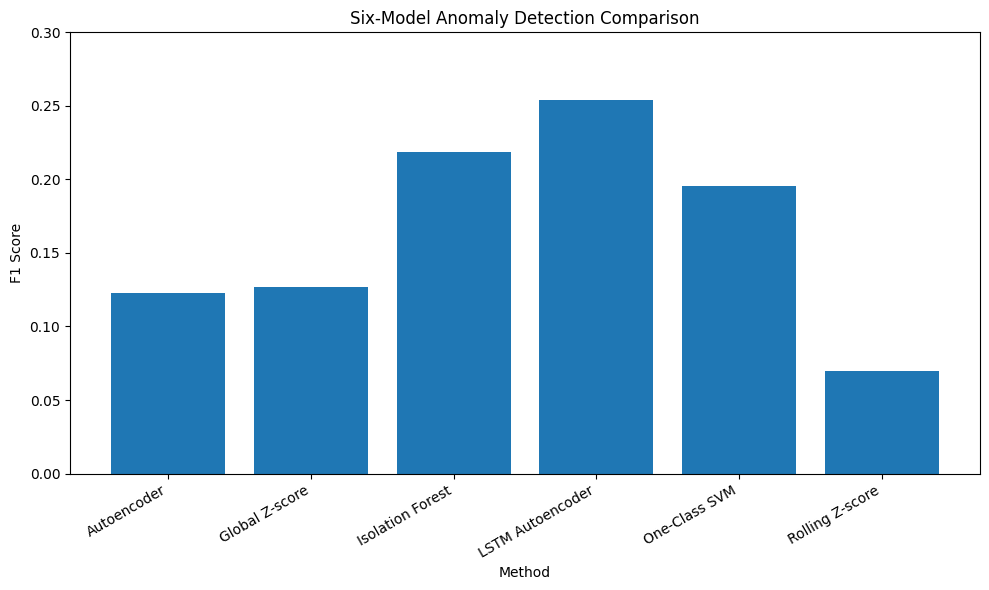

In [51]:
plt.figure(figsize=(10, 6))

plt.bar(
    fair_summary["method"],
    fair_summary["f1_score"]
)

plt.ylabel("F1 Score")
plt.xlabel("Method")
plt.title("Six-Model Anomaly Detection Comparison")
plt.xticks(rotation=30, ha="right")
plt.ylim(0, 0.30)

plt.tight_layout()
plt.show()

##Compare Precision, Recall and FPR

Now let's make a second chart because F1 alone hides the important trade-off.

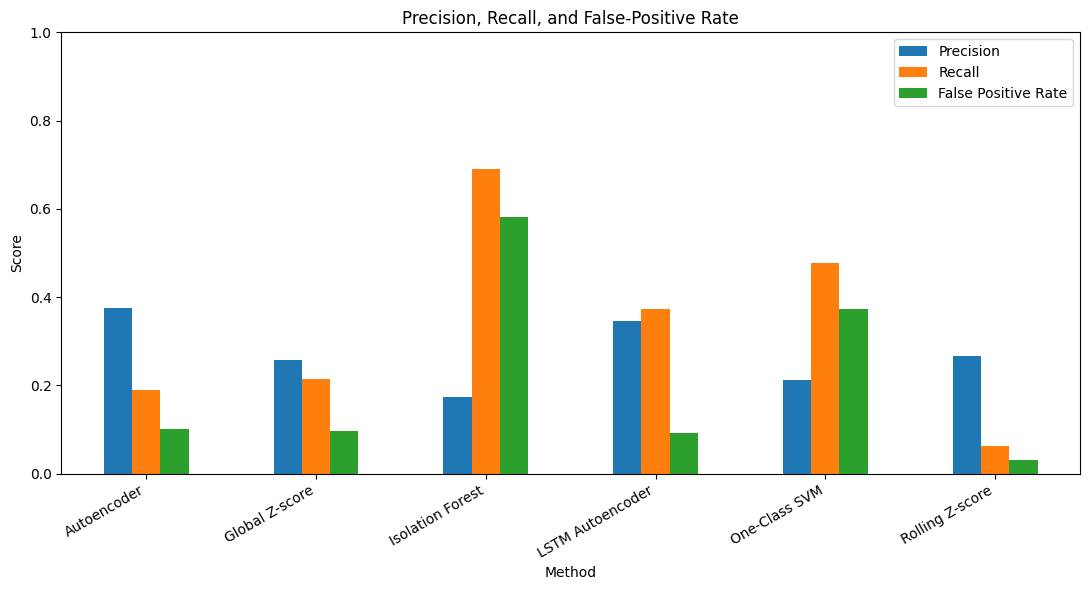

In [52]:
metrics_to_plot = [
    "precision",
    "recall",
    "false_positive_rate"
]

plot_data = fair_summary.set_index("method")[metrics_to_plot]

plot_data.plot(
    kind="bar",
    figsize=(11, 6)
)

plt.ylabel("Score")
plt.xlabel("Method")
plt.title("Precision, Recall, and False-Positive Rate")
plt.xticks(rotation=30, ha="right")
plt.ylim(0, 1)

plt.legend(
    ["Precision", "Recall", "False Positive Rate"]
)

plt.tight_layout()
plt.show()

###Generate the Final Research-Gap Summary

Now we can move to the most important part of SERIAL 25: turning these experimental results into a defensible research gap.

Existing baseline methods face a substantial trade-off between detecting spacecraft telemetry anomalies and avoiding false alarms. The results also vary considerably across telemetry channels, suggesting that a single simple detection strategy may not adequately handle different spacecraft operating behaviors and anomaly contexts.

In [53]:
research_gap_summary = {
    "evaluation_channels": len(common_channels),
    "number_of_methods": fair_summary["method"].nunique(),
    "best_mean_f1_method": fair_summary.loc[
        fair_summary["f1_score"].idxmax(),
        "method"
    ],
    "best_mean_f1": fair_summary["f1_score"].max(),
    "lowest_fpr_method": fair_summary.loc[
        fair_summary["false_positive_rate"].idxmin(),
        "method"
    ],
    "lowest_fpr": fair_summary["false_positive_rate"].min(),
    "highest_recall_method": fair_summary.loc[
        fair_summary["recall"].idxmax(),
        "method"
    ],
    "highest_recall": fair_summary["recall"].max()
}

print("SERIAL 25 Research-Gap Summary")
print("--------------------------------")
print(
    f"Common channels evaluated: "
    f"{research_gap_summary['evaluation_channels']}"
)
print(
    f"Methods compared: "
    f"{research_gap_summary['number_of_methods']}"
)
print(
    f"Highest mean F1: "
    f"{research_gap_summary['best_mean_f1_method']} "
    f"({research_gap_summary['best_mean_f1']:.3f})"
)
print(
    f"Lowest mean FPR: "
    f"{research_gap_summary['lowest_fpr_method']} "
    f"({research_gap_summary['lowest_fpr']:.3f})"
)
print(
    f"Highest mean recall: "
    f"{research_gap_summary['highest_recall_method']} "
    f"({research_gap_summary['highest_recall']:.3f})"
)

SERIAL 25 Research-Gap Summary
--------------------------------
Common channels evaluated: 67
Methods compared: 6
Highest mean F1: LSTM Autoencoder (0.254)
Lowest mean FPR: Rolling Z-score (0.031)
Highest mean recall: Isolation Forest (0.690)


### Here We have a strong baseline picture:

67 common channels

6 anomaly-detection methods

LSTM Autoencoder: highest mean F1 = 0.254

Isolation Forest: highest mean recall = 0.690, but FPR = 0.581

Rolling Z-score: lowest mean FPR = 0.031, but recall = 0.062

No method simultaneously achieves high recall and low false-alarm rate.

### Our experimental research gap:

The baseline experiments reveal a substantial trade-off between anomaly detection and false-alarm control in spacecraft telemetry. Statistical methods can maintain relatively low false-positive rates but may miss a large proportion of anomalies, while machine-learning methods can improve anomaly recall at the cost of increased false alarms. The LSTM Autoencoder achieved the highest mean F1 score among the evaluated baselines, but its recall remained moderate. These results suggest a need for an anomaly-detection approach that can better exploit contextual and temporal information while maintaining low computational cost and controlling false alarms.

##github commit

In [ ]:
%cd /content/drive/MyDrive/Spacecraft-Anomaly-Detection

!git status

!git add notebooks/25_model_comparison_and_research_gap.ipynb \
    results/lstm_autoencoder_dataset_wide.csv \
    results/six_model_fair_comparison_67_channels.csv

!git commit -m "Complete SERIAL 25 model comparison and research gap"

!git push origin main

/content/drive/MyDrive/Spacecraft-Anomaly-Detection
On branch main
Your branch is up to date with 'origin/main'.

Changes to be committed:
  (use "git restore --staged <file>..." to unstage)
	new file:   notebooks/25_model_comparison_and_research_gap.ipynb
	new file:   results/lstm_autoencoder_dataset_wide.csv
	new file:   results/six_model_fair_comparison_67_channels.csv

Changes not staged for commit:
  (use "git add <file>..." to update what will be committed)
  (use "git restore <file>..." to discard changes in working directory)
	modified:   notebooks/13_evaluate_global_zscore.ipynb
	modified:   notebooks/14_rolling_zscore.ipynb
	modified:   notebooks/15_compare_statistical_methods.ipynb
	modified:   notebooks/16_isolation_forest.ipynb
	modified:   notebooks/17_evaluate_isolation_forest.ipynb
	modified:   notebooks/18_one_class_svm.ipynb
	modified:   notebooks/19_compare_classical_methods.ipynb
	modified:   notebooks/20_autoencoder.ipynb
	modified:   notebooks/21_analyze_autoencod